In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!pip install -U git+https://github.com/qubvel/classification_models.git

  Cloning https://github.com/qubvel/classification_models.git to /tmp/pip-req-build-b55rgxea
  Running command git clone --filter=blob:none --quiet https://github.com/qubvel/classification_models.git /tmp/pip-req-build-b55rgxea
  Resolved https://github.com/qubvel/classification_models.git to commit a0f006e05485a34ccf871c421279864b0ccd220b
  Running command git submodule update --init --recursive -q
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 2.2 MB/s eta 0:00:00
  Created wheel for image_classifiers: filename=image_classifiers-1.0.0-py3-none-any.whl size=20029 sha256=9027ab02ecc4cd154de83b4e9563cc4a5dea3a627b3d7c46878dfc92b8c1f4dd
  Stored in directory: /tmp/pip-ephem-wheel-cache-k4dcv33r/wheels/14/43/ed/2d68b197c5260e7fe6b7d0fab20b997b6d365f6f5732316952
Successfully built image_classifiers


In [2]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelBinarizer
from classification_models.tfkeras import Classifiers
from tensorflow.keras.layers import (Input, Conv2D, GlobalAveragePooling2D,
                                     Dense, Multiply, Add, Concatenate, Reshape,
                                     Activation, Lambda)
from tensorflow.keras.models import Model

2025-04-28 10:18:22.670649: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745835502.913907      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745835502.985623      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
dataset_path = '/kaggle/input/corn-or-maize-leaf-disease-dataset/data'
img_size = (128, 128)
batch_size = 32
AUTOTUNE = tf.data.AUTOTUNE

In [7]:
full_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='int',
    shuffle=True,  # shuffle data before splitting
    validation_split=0.2,  # Split into training and validation sets
    subset="training",  # Set this to "training" for the training subset
    seed=123
)


Found 4188 files belonging to 4 classes.
Using 3351 files for training.


In [8]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='int',
    shuffle=True,
    validation_split=0.2,
    subset="validation",  # Set this to "validation" for the validation subset
    seed=123
)

Found 4188 files belonging to 4 classes.
Using 837 files for validation.


In [9]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='int',
    shuffle=True  # No split, we assume it's a separate test set
)

Found 4188 files belonging to 4 classes.


In [10]:
train_ds = full_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [11]:
ResNet34, preprocess_input = Classifiers.get('resnet34')
preprocess_layer = tf.keras.layers.Lambda(lambda x: preprocess_input(x))

In [12]:
def Cosin_similarity(tensors):
    a, b = tensors
    dot_product = tf.reduce_sum(a * b, axis=-1, keepdims=True)
    norm_a = tf.norm(a, axis=-1, keepdims=True)
    norm_b = tf.norm(b, axis=-1, keepdims=True)
    return dot_product / (norm_a * norm_b + tf.keras.backend.epsilon())

In [13]:
def Bund(inputs):
    alpha_1, alpha_2 = inputs
    total = alpha_1 + alpha_2 + tf.keras.backend.epsilon()
    alpha_l = alpha_1 / total
    alpha_g = alpha_2 / total
    return alpha_l, alpha_g

In [14]:
def eca_module(input_tensor, gamma=2):
    channels = input_tensor.shape[-1]
    squeeze = GlobalAveragePooling2D()(input_tensor)
    excitation = Dense(units=channels // gamma)(squeeze)
    excitation = Activation('relu')(excitation)
    excitation = Dense(units=channels)(excitation)
    excitation = Activation('sigmoid')(excitation)
    excitation = Reshape((1, 1, channels))(excitation)
    scale = Multiply()([input_tensor, excitation])
    output = Add()([scale, input_tensor])
    return output

In [15]:
def res_csa_module(input_tensor, reduction_ratio=16):
    channels = input_tensor.shape[-1]
    conv1 = Conv2D(filters=channels // reduction_ratio, kernel_size=(1,1), padding='same', activation='relu')(input_tensor)
    conv2 = Conv2D(filters=channels // reduction_ratio, kernel_size=(1,1), padding='same', activation='relu')(conv1)
    conv3 = Conv2D(filters=channels, kernel_size=(1,1), padding='same', activation='relu')(conv2)
    attention_map = Conv2D(filters=1, kernel_size=(1,1), padding='same', activation='sigmoid')(conv3)
    attention = Multiply()([attention_map, input_tensor])
    output = Add()([attention, input_tensor])
    return output

In [16]:
def build_model(input_shape, num_classes):
    input_tensor = Input(shape=input_shape)
    x = preprocess_layer(input_tensor)
    backbone_output = ResNet34(input_shape=input_shape, weights='imagenet', include_top=False)(x)
    eca_out = eca_module(backbone_output)
    res_csa_out = res_csa_module(backbone_output)
    x = Add()([backbone_output, eca_out, res_csa_out])
    x_l = GlobalAveragePooling2D()(eca_out)
    x_g = GlobalAveragePooling2D()(res_csa_out)
    x_c = GlobalAveragePooling2D()(x)
    x_l = Dense(384, activation='relu')(x_l)
    x_g = Dense(384, activation='relu')(x_g)
    x_c = Dense(384, activation='relu')(x_c)
    share_1 = Dense(768, activation='relu')
    share_2 = Dense(768, activation='relu')
    x_l = share_1(x_l)
    x_g = share_1(x_g)
    x_c = share_1(x_c)
    x_l = share_2(x_l)
    x_g = share_2(x_g)
    x_c = share_2(x_c)
    x_l = Dense(num_classes, activation='softmax')(x_l)
    x_g = Dense(num_classes, activation='softmax')(x_g)
    x_c = Dense(num_classes, activation='softmax')(x_c)
    alpha_1 = Lambda(Cosin_similarity)([x_l, x_c])
    alpha_2 = Lambda(Cosin_similarity)([x_g, x_c])
    alpha_l, alpha_g = Lambda(Bund)([alpha_1, alpha_2])
    out_l = Multiply()([alpha_l, x_l])
    out_g = Multiply()([alpha_g, x_g])
    out = Concatenate()([out_l, out_g])
    out = Dense(64, activation='relu')(out)
    out = Dense(num_classes, activation='softmax')(out)
    model = Model(inputs=input_tensor, outputs=out)
    return model

In [17]:
from tensorflow.keras.optimizers.schedules import ExponentialDecay

lr_schedule = ExponentialDecay(
    initial_learning_rate=1e-4,
    decay_steps=100000,
    decay_rate=0.96,
    staircase=True
)

optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

In [18]:
model = build_model(input_shape=img_size + (3,), num_classes=len(full_ds.class_names))
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

85521592/85521592 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 128, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda (Lambda)           │ (None, 128, 128, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ functional (Functional)   │ (None, 4, 4, 512)      │     21,302,473 │ lambda[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d  │ (None, 512)            │              0 │ functional[0][0]       │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 256)            │        131,328 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation (Activation)   │ (None, 256)            │              0 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 4, 4, 32)       │         16,416 │ functional[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 512)            │        131,584 │ activation[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 4, 4, 32)       │          1,056 │ conv2d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_1 (Activation) │ (None, 512)            │              0 │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 4, 4, 512)      │         16,896 │ conv2d_1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape (Reshape)         │ (None, 1, 1, 512)      │              0 │ activation_1[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 4, 4, 1)        │            513 │ conv2d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply (Multiply)       │ (None, 4, 4, 512)      │              0 │ functional[0][0],      │
│                           │                        │                │ reshape[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply_1 (Multiply)     │ (None, 4, 4, 512)      │              0 │ conv2d_3[0][0],        │
│                           │                        │                │ functional[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_16 (Add)              │ (None, 4, 4, 512)      │              0 │ multiply[0][0],        │
│                           │                        │                │ functional[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_17 (Add)              │ (None, 4, 4, 512)      │              0 │ multiply_1[0][0],      │
│                           │                        │                │ functional[0][0]       │
├──────────────────────

 Total params: 23,087,578 (88.07 MB)

 Trainable params: 23,072,212 (88.01 MB)

 Non-trainable params: 15,366 (60.02 KB)

In [19]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100
)

Epoch 1/100


I0000 00:00:1745835816.807684     166 service.cc:148] XLA service 0x7fc9d40029b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745835816.809024     166 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1745835816.809045     166 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1745835820.096646     166 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/105 ━━━━━━━━━━━━━━━━━━━━ 1:27:48 51s/step - accuracy: 0.1875 - loss: 1.3878

I0000 00:00:1745835834.973142     166 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


105/105 ━━━━━━━━━━━━━━━━━━━━ 89s 371ms/step - accuracy: 0.6271 - loss: 1.2731 - val_accuracy: 0.8232 - val_loss: 1.1625
Epoch 2/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 12s 111ms/step - accuracy: 0.8400 - loss: 1.1334 - val_accuracy: 0.8280 - val_loss: 1.0814
Epoch 3/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 12s 113ms/step - accuracy: 0.8390 - loss: 1.0544 - val_accuracy: 0.8172 - val_loss: 1.0136
Epoch 4/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 12s 115ms/step - accuracy: 0.8240 - loss: 0.9897 - val_accuracy: 0.8363 - val_loss: 0.9295
Epoch 5/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 12s 119ms/step - accuracy: 0.8494 - loss: 0.8987 - val_accuracy: 0.8315 - val_loss: 0.8644
Epoch 6/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 13s 122ms/step - accuracy: 0.8417 - loss: 0.8383 - val_accuracy: 0.7838 - val_loss: 0.8613
Epoch 7/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 13s 121ms/step - accuracy: 0.8377 - loss: 0.7842 - val_accuracy: 0.8160 - val_loss: 0.7748
Epoch 8/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step - accuracy: 0.8327 - loss: 0.738

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━

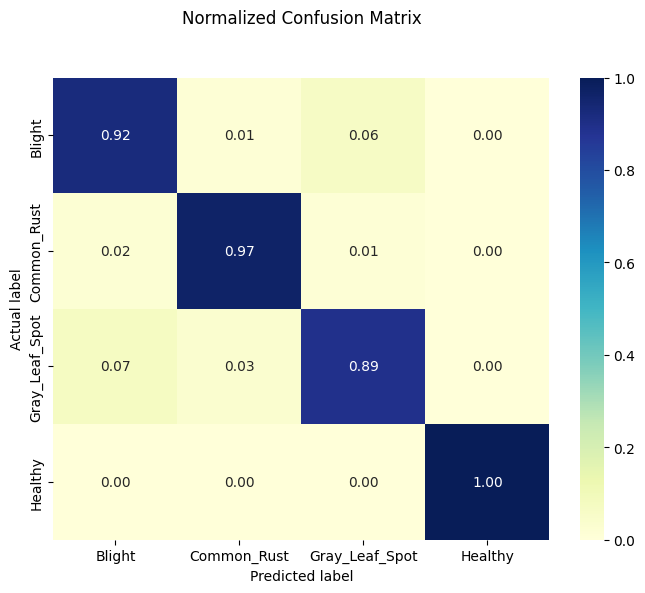

In [22]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Generate predictions and true labels
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=-1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Define your class names (make sure this matches your dataset)
target_names = full_ds.class_names  # ['cbb', 'cbsd', 'cgm', 'cmd', 'healthy']

# Create the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Normalize the confusion matrix
cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(pd.DataFrame(cm), annot=True, fmt='.2f', cmap="YlGnBu",
            xticklabels=target_names, yticklabels=target_names)

plt.title('Normalized Confusion Matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

In [23]:
test_loss, test_accuracy = model.evaluate(val_ds)

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9509 - loss: 0.2717


In [24]:
class_report = classification_report(y_true, y_pred, target_names=full_ds.class_names)
print("\nClassification Report:\n", class_report)


Classification Report:
                 precision    recall  f1-score   support

        Blight       0.94      0.92      0.93       222
   Common_Rust       0.97      0.97      0.97       248
Gray_Leaf_Spot       0.87      0.89      0.88       122
       Healthy       1.00      1.00      1.00       245

      accuracy                           0.95       837
     macro avg       0.94      0.95      0.94       837
  weighted avg       0.95      0.95      0.95       837



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━

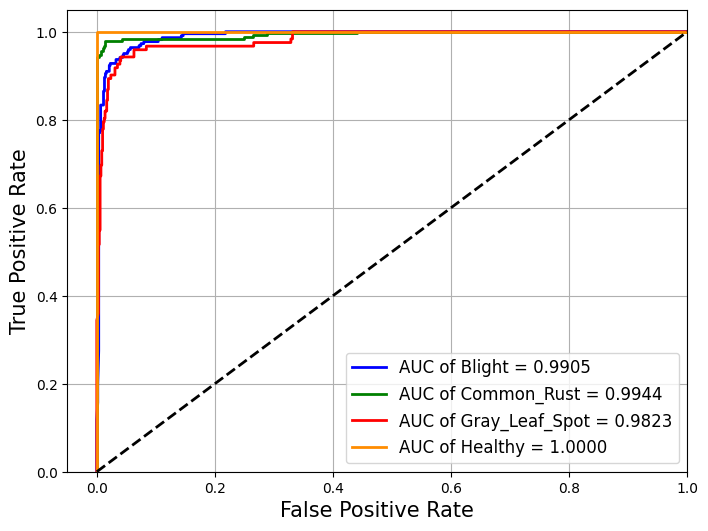

In [27]:
from sklearn.metrics import roc_curve, auc
from itertools import cycle
import matplotlib.pyplot as plt
import numpy as np

# First get the true labels and predicted probabilities
y_true = []
y_pred_probs = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred_probs.extend(preds)  # we need raw probabilities, not hard predictions!

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)

# FIX: Define number of classes
num_classes = len(full_ds.class_names)

# Convert y_true into one-hot encoding
y_true_onehot = tf.keras.utils.to_categorical(y_true, num_classes=num_classes)

# Initialize dicts
fpr = dict()
tpr = dict()
roc_auc = dict()
lw = 2

# Compute ROC curve and ROC area for each class
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plotting
colors = cycle(['blue', 'green', 'red', 'darkorange', 'olive','yellow'])  # use any colors you like
plt.figure(figsize=(8, 6))

for i, color in zip(range(num_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
             label='AUC of {0} = {1:0.4f}'.format(full_ds.class_names[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=lw)
plt.xlim([-0.05, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=15)
plt.ylabel('True Positive Rate', fontsize=15)
plt.legend(loc="lower right", fontsize=12)
plt.grid()
plt.show()